In [1]:
import torch
from torchvision import datasets,transforms

In [2]:
#Loading a dataset from images
df=datasets.ImageFolder(root="/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train")

In [3]:
#Splitting the dataset, before applying augmentation on the training set
torch.manual_seed(42)
from torch.utils.data import random_split
train_size=int(0.8*len(df))
val_size=len(df)-train_size
df_train,df_val=random_split(df,[train_size,val_size])

In [4]:
#Applying Data augmentation and normalizing
train_pipeline=transforms.Compose([transforms.Resize((144,144)),transforms.RandomCrop(128),
                                   transforms.RandomRotation(10),
                                   transforms.ColorJitter(brightness=0.2,contrast=0.2),
                                   transforms.RandomGrayscale(p=0.05),transforms.ToTensor(),
                                   transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
#Normalization Pipeline
val_test_pipeline=transforms.Compose([transforms.Resize((128,128)),transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])

In [5]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class TestDataset(Dataset):
    def __init__(self,csv_file,kaggle_dataset,mapping,transform=None):
        self.df=pd.read_csv(csv_file)
        self.kaggle_dataset=kaggle_dataset
        self.mapping=mapping
        self.transform=transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        img_path=os.path.join(self.kaggle_dataset,self.df.iloc[idx]["Path"])

        label=self.mapping[str(self.df.iloc[idx]["ClassId"])]
        image=Image.open(img_path).convert("RGB")

        if self.transform:
            image=self.transform(image)

        return image,label

In [6]:
#Created a class to apply the tranform pipelines on the dataset
class TransformerDataset(torch.utils.data.Dataset):
    def __init__(self,df,transformation_pipeline):
        self.df=df
        self.transform=transformation_pipeline
    def __len__(self):
        return len(self.df)
    def __getitem__(self,index):
        img,label=self.df[index]
        return self.transform(img),label
        

In [7]:
#Transformed the dataset
df_train=TransformerDataset(df_train,train_pipeline)
df_val=TransformerDataset(df_val,val_test_pipeline)
df_test=TestDataset(csv_file="/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv",kaggle_dataset="/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign",mapping=df.class_to_idx,transform=val_test_pipeline)

In [8]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"

In [9]:
from torch.utils.data import DataLoader
train_loader=DataLoader(df_train,shuffle=True,batch_size=64,num_workers=4)
val_loader=DataLoader(df_val,shuffle=False,batch_size=64,num_workers=4)
test_loader=DataLoader(df_test,shuffle=False,batch_size=64,num_workers=4)

In [10]:
import torch.nn as nn

In [11]:
#Residual Block to later be used, each block consists of 2 layers and an option to be downsampled
class ResidualBlock(nn.Module):
    def __init__(self,in_channels,n_kernels,downsample):
        super().__init__()
        #self.conv1 is the first layer of the residual block if downsample=False
        self.conv1=nn.Sequential(
            nn.Conv2d(in_channels,out_channels=n_kernels,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(n_kernels))
        
        #self.convdown is the first layer of the residual block in case of downsample=True
        self.convdown=nn.Sequential(
            nn.Conv2d(in_channels,out_channels=n_kernels,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(n_kernels))

        #self.conv2 is the second layer of the residual block in both cases
        self.conv2=nn.Sequential(
            nn.Conv2d(n_kernels,n_kernels,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(n_kernels))
        
        #self.down helps preparing the input for concatenation later if downsample=True
        self.down=nn.Sequential(             
            nn.Conv2d(in_channels,out_channels=n_kernels,kernel_size=1,stride=2),
            nn.BatchNorm2d(n_kernels))
        
        self.relu=nn.ReLU()

        #To check if the architecture wants downsample or not
        self.downsample=downsample
    def forward(self,X):
        if self.downsample:
            skip_set=self.down(X)
            output=self.convdown(X)
            output=self.relu(output)
            output=self.conv2(output)
            concat_set=output+skip_set
            final_output=self.relu(concat_set)

        else:
            output=self.conv1(X)
            output=self.relu(output)
            output=self.conv2(output)
            concat_set=output+X
            final_output=self.relu(concat_set)

        return final_output

In [12]:
#The Inception Block consists of two kernel of sizes:5 and 3 and one maxpool,and the outputs tensors are calculated using a bottleneck to reduce the cost of computation
#The output of all three go through Batch normalization and ReLU activation individually and finally they go under concatation
class InceptionBlock(nn.Module):
    def __init__(self,in_channels,out_five,out_three,out_maxpool,five_bottle,three_bottle):
        super().__init__()
        self.conv5d=nn.Sequential(nn.Conv2d(in_channels,out_channels=five_bottle,kernel_size=1),
                                  nn.Conv2d(in_channels=five_bottle,out_channels=out_five,padding="same",kernel_size=5),
                                  nn.BatchNorm2d(out_five),
                                  nn.ReLU())
        self.conv3d=nn.Sequential(nn.Conv2d(in_channels,out_channels=three_bottle,kernel_size=1),
                                  nn.Conv2d(in_channels=three_bottle,out_channels=out_three,padding="same",kernel_size=3),
                                  nn.BatchNorm2d(out_three),
                                  nn.ReLU())
        self.maxpool=nn.Sequential(nn.MaxPool2d(padding=1,stride=1,kernel_size=3),
                                   nn.Conv2d(in_channels,out_channels=out_maxpool,kernel_size=1),
                                   nn.BatchNorm2d(out_maxpool),
                                   nn.ReLU())

    def forward(self,X):
        conv5_output=self.conv5d(X)
        conv3_output=self.conv3d(X)
        maxpool_output=self.maxpool(X)
        output=torch.concat([conv5_output,conv3_output,maxpool_output],dim=1)
        return output
        
        

In [13]:
class CNN(nn.Module):
    def __init__(self,n_image_channel):
        super().__init__()
        self.cnn_layer=nn.Sequential(nn.Conv2d(n_image_channel,out_channels=32,kernel_size=3,padding="same"),
                                     nn.BatchNorm2d(32),
                                     nn.ReLU(),
                                     nn.Conv2d(32,out_channels=32,kernel_size=3,padding="same"),
                                     nn.BatchNorm2d(32),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2,stride=2),
                                     InceptionBlock(32,out_five=64,out_three=128,out_maxpool=64,five_bottle=16,three_bottle=16),
                                     nn.MaxPool2d(kernel_size=2,stride=2),
                                     InceptionBlock(256,out_five=64,out_three=128,out_maxpool=64,five_bottle=64,three_bottle=64),
                                     ResidualBlock(256,512,downsample=True),
                                     ResidualBlock(512,512,downsample=False),
                                     nn.AdaptiveAvgPool2d((1,1)),
                                     nn.Flatten())
        self.neuron_layer=nn.Sequential(nn.Linear(512,512),
                                        nn.BatchNorm1d(512),
                                        nn.ReLU(),
                                        nn.Dropout(p=0.3),
                                        nn.Linear(512,43))
    def forward(self,X):
        convolution_output=self.cnn_layer(X)
        final_output=self.neuron_layer(convolution_output)
        return final_output
        

In [14]:
#Using Adam as the Optimizer
model=CNN(n_image_channel=3).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001,betas=(0.9,0.999),weight_decay=1e-4)
criterion=nn.CrossEntropyLoss()
learning_rate_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",patience=5,factor=0.5,min_lr=1e-6)

In [15]:
#Training consists of early stopping with a patience of 7 and maximum epochs as n_epochs
losses_list=list()
val_losses_list=list()
def training(train_loader,val_loader,model,optimizer,criterion,learning_rate_scheduler,n_epochs):
    best_val_acc=0
    patience=0
    for epoch in range(n_epochs):
        model.train()
        losses=0.0
        if patience>6:
            break
        for image_batch,label_batch in train_loader:
            image_batch=image_batch.to(device)
            label_batch=label_batch.to(device)
            optimizer.zero_grad()
            y_probab=model(image_batch)
            loss=criterion(y_probab,label_batch)
            loss.backward()
            optimizer.step()
            losses+=loss.item()
        mean_loss=losses/len(train_loader)
        losses_list.append(mean_loss)
        
        model.eval()
        total_predictions=len(val_loader.dataset)
        correct_predictions=0
        with torch.no_grad():
         val_losses=0.0
         for image_batch,label_batch in val_loader:
          image_batch=image_batch.to(device)
          label_batch=label_batch.to(device)
          y_probab=model(image_batch)
          val_loss=criterion(y_probab,label_batch)
          val_losses+=val_loss.item()
          ignore,y_preds=torch.max(y_probab,axis=1)
          correct_predictions+=(y_preds==label_batch).sum().item()
        val_acc=correct_predictions/total_predictions
        val_mean_loss=val_losses/len(val_loader)
        val_losses_list.append(val_mean_loss)
        learning_rate_scheduler.step(val_acc)
        print(f"Epoch:{epoch},Mean Loss:{mean_loss},Val_accuracy:{val_acc:.5f}",flush=True)
        
        #Early Stopping
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            best_epoch=epoch
            best_model=model.state_dict().copy()
            patience=0 #We only track patience for consecutive non-repeating loops
        else:
            patience+=1
    
    #Saving the best model for evaluation purposes 
    torch.save(best_model,"/kaggle/working/bestmodel.pth")
    print(f"The best model is found at the epoch:{best_epoch} with a validation accuracy of {best_val_acc}")

In [16]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
def eval(test_loader,model):
    model.eval()
    total_preds=[]
    total_labels=[]
    with torch.no_grad():
        for image_batch,label_batch in test_loader:
            image_batch=image_batch.to(device)
            y_probab=model(image_batch)
            y_preds=torch.argmax(y_probab,dim=1)
            total_preds.extend(y_preds.cpu().numpy())
            total_labels.extend(label_batch.numpy())

    accuracy=accuracy_score(total_labels,total_preds)
    precision=precision_score(total_labels,total_preds,average="weighted")
    recall=recall_score(total_labels,total_preds,average="weighted")
    f1=f1_score(total_labels,total_preds,average="weighted")
    cm=confusion_matrix(total_labels,total_preds)
    return accuracy,precision,recall,f1,cm

In [17]:
def plot_confusion_matrix(confusion_matrix):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    class_names=[str(i) for i in range(43)]
    df_cm=pd.DataFrame(confusion_matrix,index=class_names,columns=class_names).astype(int)
    plt.figure(figsize=(16,14))
    ax=sns.heatmap(df_cm,cmap="Blues")
    ax.set_xlabel("Predicted Label",labelpad=12)
    ax.set_ylabel("Actual Label ",labelpad=12)
    plt.show()

In [18]:
#Maximum epochs set to 80
training(train_loader,val_loader,model,optimizer,criterion,learning_rate_scheduler,n_epochs=80)

Epoch:0,Mean Loss:2.2864367789503515,Val_accuracy:0.48100
Epoch:1,Mean Loss:0.47725310851108516,Val_accuracy:0.74815
Epoch:2,Mean Loss:0.10590472726185489,Val_accuracy:0.91163
Epoch:3,Mean Loss:0.06593430646298767,Val_accuracy:0.97985
Epoch:4,Mean Loss:0.05162345244057947,Val_accuracy:0.96621
Epoch:5,Mean Loss:0.047720132513225925,Val_accuracy:0.95269
Epoch:6,Mean Loss:0.04003937064329553,Val_accuracy:0.96723
Epoch:7,Mean Loss:0.03876589241488827,Val_accuracy:0.89875
Epoch:8,Mean Loss:0.033904042842043014,Val_accuracy:0.85654
Epoch:9,Mean Loss:0.03811146042609868,Val_accuracy:0.99464
Epoch:10,Mean Loss:0.02637324843777613,Val_accuracy:0.98674
Epoch:11,Mean Loss:0.023774534537560777,Val_accuracy:0.94797
Epoch:12,Mean Loss:0.0207181417296357,Val_accuracy:0.99209
Epoch:13,Mean Loss:0.022668804335094942,Val_accuracy:0.99401
Epoch:14,Mean Loss:0.020316337048082733,Val_accuracy:0.98891
Epoch:15,Mean Loss:0.017605282556665814,Val_accuracy:0.99515
Epoch:16,Mean Loss:0.017022159584686957,Val_ac

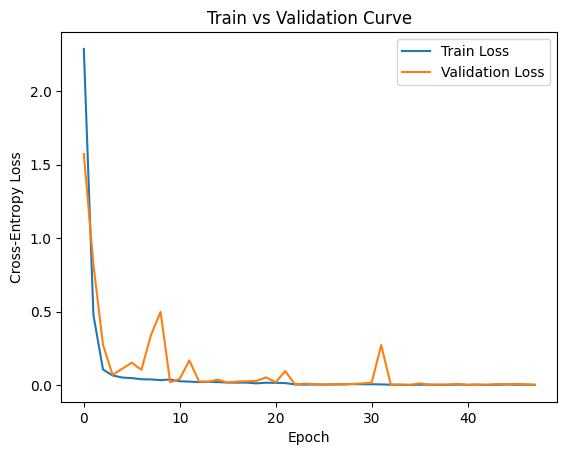

In [19]:
#Training Vs Validation Loss Plot
import matplotlib.pyplot as plt
plt.plot(losses_list,label="Train Loss")
plt.plot(val_losses_list,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Train vs Validation Curve")
plt.legend()
plt.show()

Accuracy:0.9900237529691212
Precision:0.9903334238524973
Recall:0.9900237529691212
F1:0.9900147213760446


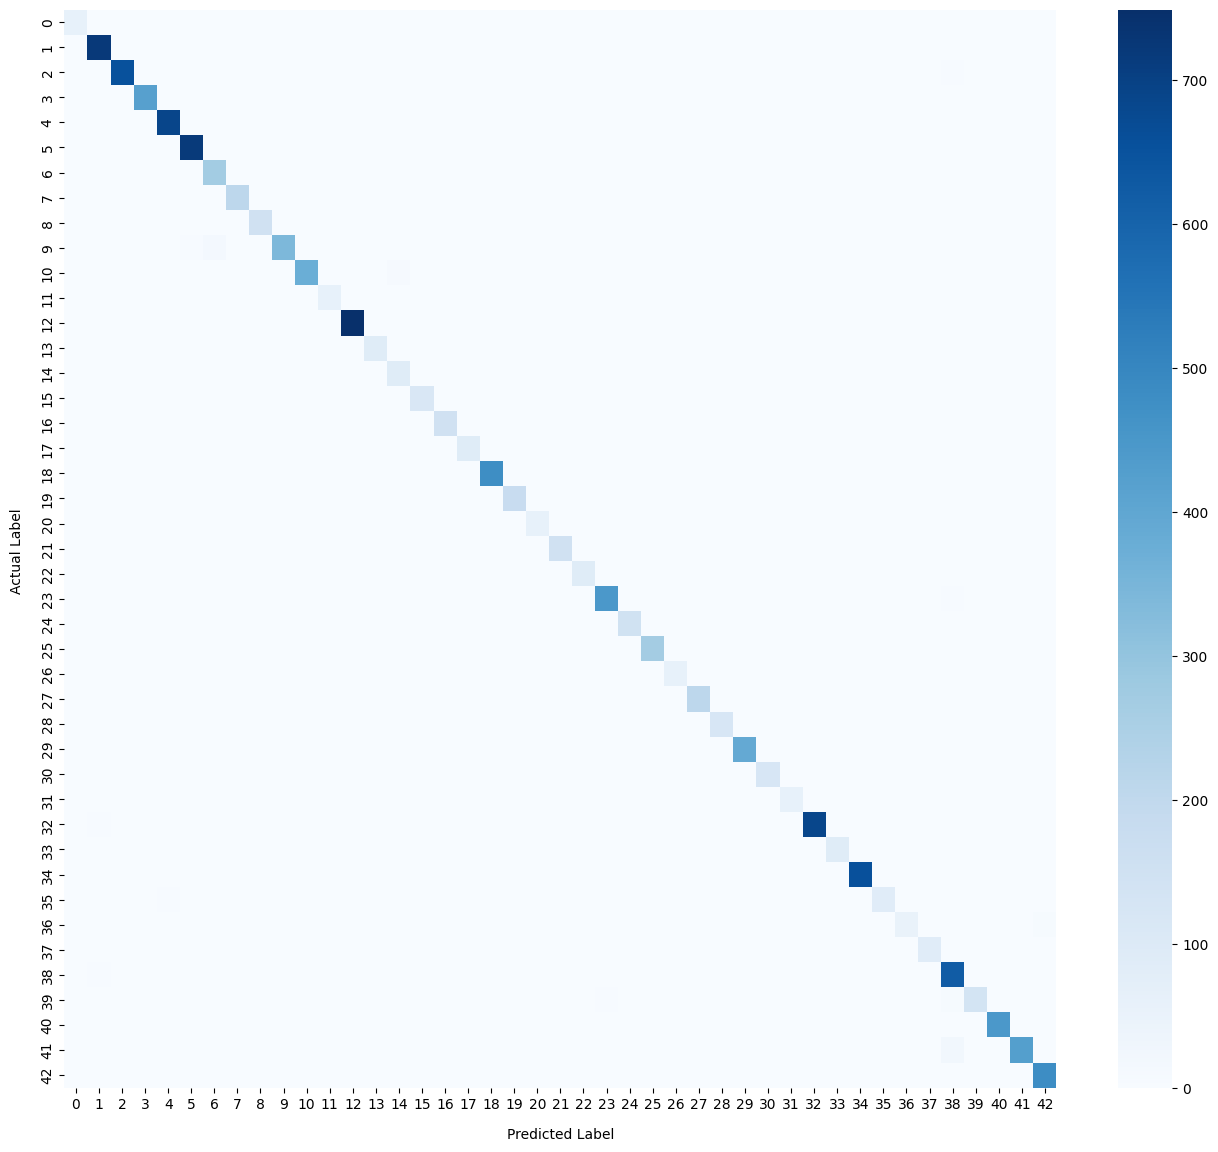

In [20]:
#Using the best model found in training during the process of Early Stopping for evaluation of TEST Set
model.load_state_dict(torch.load('/kaggle/working/bestmodel.pth'))

#Test Accuracy
accuracy,precision,recall,f1,cm=eval(test_loader, model)
print(f"Accuracy:{accuracy}")
print(f"Precision:{precision}")
print(f"Recall:{recall}")
print(f"F1:{f1}")
plot_confusion_matrix(cm)

In [21]:
#Gradcam class to hook,generate the CAM tensor and display it 
class GradCam():
    def __init__(self):
        self.forward_value=None                   #Initially setting the activations in the hook as zero
        self.back_gradient=None                   #Initially setting the gradients in the hook as zero

    
    def forward(self,module,input,output):        
        self.forward_value=output                 #self.forward_value stores the activations of the hook layer
           
    def backward(self,module,input,gradient_output):
        self.back_gradient=gradient_output[0]     #self.back_gradient stores the gradients of the hook layer

    def generate_cam(self):
        #Taking alpha as the mean of gradients of each channel in the tensor of the final Convolutional Layer
        alpha=(self.back_gradient).mean(dim=(2,3))
        alpha=alpha.reshape(1,-1,1,1)
        #Taking the weighted sum of alphas and the layers which the CAM tensor
        weighted_sum=((self.forward_value*alpha).sum(axis=1))[0]
        #Taking the RELU to keep only those who positively contribute towards the prediction
        final_output=torch.relu(weighted_sum)
        return final_output

    def visualize(self,original_image,cam_output):
         #Plotting the original image and jet colormap on top of it with an alpha of 0.4
         import torch.nn.functional as functional
         import matplotlib.pyplot as plt
         cam=cam_output.unsqueeze(0).unsqueeze(0)             #Preprocessing the GradCam to be displayed the same size as the image
         cam=functional.interpolate(cam,size=(128,128))
         cam_normalized=(cam-cam.min())/(cam.max()-cam.min()) #Normalizing the CAM
         plt.imshow(original_image.permute(1,2,0))
         plt.imshow(cam_normalized[0][0].detach().cpu().numpy(),alpha=0.4,cmap="jet") #Converting tensor back to numpy to be used by Matplotlib
         plt.show()

In [22]:
#The test images need to be denormalized to be seen properly when we use visualize
def denormalize(img):
    mean=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (img*std) + mean

In [23]:
def Gradcam_visualize(model,img_label,cam_layer):
    #Applying hooks and diplaying the image along with the correct label and the predicted label
    gradcam=GradCam()
    forward_hook=cam_layer.register_forward_hook(gradcam.forward)
    backward_hook=cam_layer.register_full_backward_hook(gradcam.backward)
    img,label=img_label
    img1=denormalize(img)
    y_probab=model(img.unsqueeze(0).to(device))
    y_max=y_probab.argmax().item()
    y_true=y_probab[0,label]
    model.zero_grad()
    y_true.backward()
    forward_hook.remove()
    backward_hook.remove()
    cam_output=gradcam.generate_cam()
    gradcam.visualize(img1,cam_output)
    print(f"True Label:{df.classes[label]},Predicted Label:{df.classes[y_max]}")

In [24]:
#Seeing the GradCam of different Test-Set predictions 

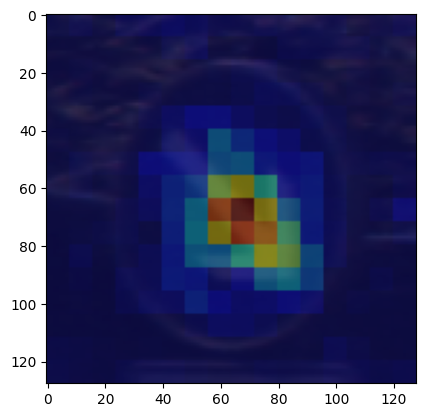

True Label:38,Predicted Label:38


In [25]:
cam_layer=model.cnn_layer[11]
Gradcam_visualize(model,df_test[211],cam_layer)

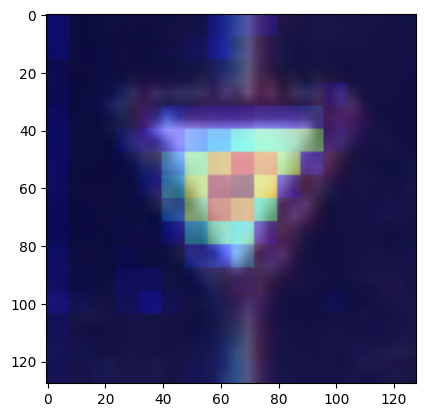

True Label:13,Predicted Label:13


In [26]:
Gradcam_visualize(model,df_test[911],cam_layer)

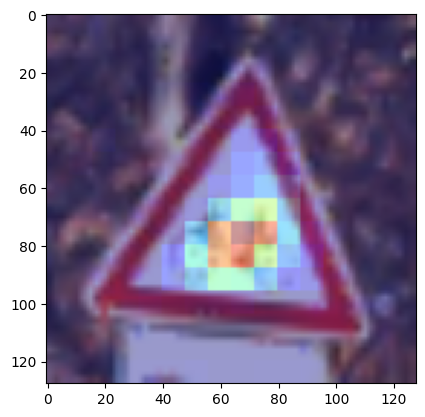

True Label:29,Predicted Label:29


In [27]:
Gradcam_visualize(model,df_test[341],cam_layer)

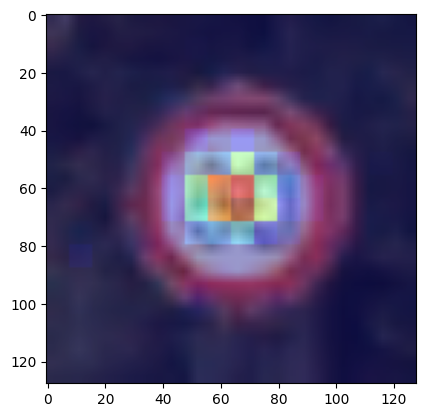

True Label:5,Predicted Label:5


In [28]:
Gradcam_visualize(model,df_test[1231],cam_layer)

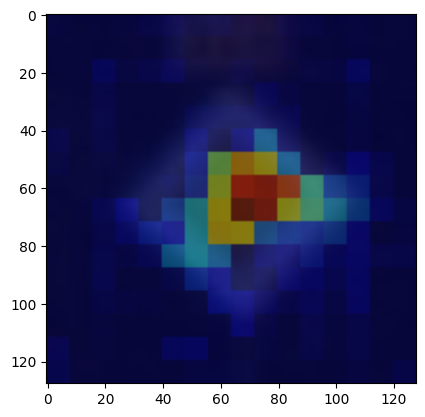

True Label:12,Predicted Label:12


In [29]:
Gradcam_visualize(model,df_test[2221],cam_layer)

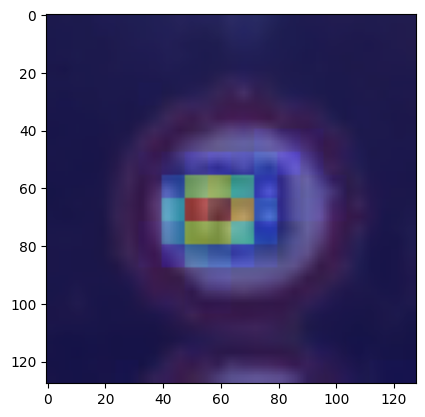

True Label:8,Predicted Label:8


In [30]:
Gradcam_visualize(model,df_test[3121],cam_layer)